In [1]:
import torch
import torch.nn as nn
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import scipy.integrate as integrate
import time

from pyDOE import lhs

In [2]:
# CUDA support 
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
    
print(device)

cuda


In [3]:
torch.cuda.set_device(1)
torch.manual_seed(1234)
np.random.seed(1234)

In [ ]:
checkpoint_dir = os.path.dirname(r"/.../weights/model 1_1/cp-{epoch:06d}.ckpt")
# os.mkdir(checkpoint_dir)
checkpoint_path_ffm = checkpoint_dir + "/ffm/cp-{epoch:06d}.ckpt"
checkpoint_path_ffm_best = checkpoint_dir + "/ffm/best-cp.ckpt"
checkpoint_dir_ffm = os.path.dirname(checkpoint_path_ffm)
# os.mkdir(checkpoint_dir_ffm)
checkpoint_path_ffp = checkpoint_dir + "/ffp/cp-{epoch:06d}.ckpt"
checkpoint_path_ffp_best = checkpoint_dir + "/ffp/best-cp.ckpt"
checkpoint_dir_ffp = os.path.dirname(checkpoint_path_ffp)
# os.mkdir(checkpoint_dir_ffp)


In [5]:
# number_layers = 8
number_neurons = 40
output_size = 1

In [6]:
def initialize_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight.data)
        nn.init.constant_(m.bias.data, 0)

In [7]:
def init_model(input_size, layers, output_size = output_size, layer_width = number_neurons):
    model = nn.Sequential() 
    model.add_module("dense_0", nn.Linear(input_size, layer_width))
    model.add_module("activation_0", nn.Tanh())
    
    for i in range(1, layers):
        model.add_module('dense_%d' % i, nn.Linear(layer_width, layer_width))
        model.add_module('activation_%d' % i, nn.Tanh())

    model.add_module('dense_' + str(i+1), nn.Linear(layer_width, output_size))
    model.add_module('activation_%d' % i, nn.Sigmoid())
    
    return model

In [8]:
ffm = init_model(input_size = 2, layers = 10)
ffm.apply(initialize_weights)
ffm = ffm.to(device)

ffp = init_model(input_size = 2, layers = 8)
ffp.apply(initialize_weights)
ffp = ffp.to(device)

In [9]:
iter_ = 100000

delta = 5e-2

a_t = 0
b_t = 0.5 #2
a_xi = - delta
b_xi = delta


number_of_grid_xi = 5000
number_of_grid_t = 5000

N  = (b_xi - a_xi)*number_of_grid_xi
Nt = (b_t - a_t)*number_of_grid_t
h_ = (b_xi - a_xi)/N
k = (b_t - a_t)/Nt

t = np.arange(a_t, b_t, k)
xi = np.arange(a_xi, b_xi, h_)
Xi, T = np.meshgrid(xi, t)

In [10]:
U_exact = np.load(checkpoint_dir + r"/U_exact.npy")
# U_exact = U_exact[,]
print(U_exact.shape)

(2500, 500)


In [11]:
# U_exact_new = U_exact

In [12]:
gap = int(U_exact.shape[0] / len(t))
print(gap)

indices = np.arange(0,U_exact.shape[0],gap)

U_exact_new = U_exact[indices]

1


In [ ]:
C_star = 0.1
eta = 1

d1 = 1
d2 = 1e-2

k1 = 1
k2 = 1

In [14]:
N_bc = 200
N_f = 100

In [ ]:
h = lambda t, c = C_star, eta = eta : eta * t + c
h_prime = lambda t, eta = eta: np.ones(t.shape) * eta


In [16]:
def q1(xi, t, d1=d1, h=h, hprime=h_prime):
    return hprime(t) + (d1/(xi+h(t)))

def q2(xi, t, d2=d2, h=h, hprime=h_prime):
    return hprime(t) + (d2/(xi+h(t)))

In [ ]:
U_ic_train = U_exact_new[0,:][:-2]

In [ ]:
xx1 = np.hstack((Xi[0:1,:].T, T[0:1,:].T)) #initial condition
X_ic_train = xx1

cond_ic = X_ic_train[:,0:1] < 0
X_ic1_train = np.where(cond_ic, X_ic_train, np.nan)
X_ic1_train = X_ic1_train[~np.isnan(X_ic1_train).any(axis=1)]
U_ic1_train = U_ic_train[:X_ic1_train.shape[0]]  
U_ic1_train = np.reshape(U_ic1_train, (U_ic1_train.shape[0], 1))
print(X_ic1_train.shape)
print(U_ic1_train.shape)

X_ic2_train = np.where(cond_ic, np.nan, X_ic_train)
X_ic2_train = X_ic2_train[~np.isnan(X_ic2_train).any(axis=1)]
U_ic2_train = U_ic_train[X_ic2_train.shape[0]:]  
U_ic2_train = np.reshape(U_ic2_train, (U_ic2_train.shape[0], 1))
print(X_ic2_train.shape)
print(U_ic2_train.shape)

(251, 2)
(251, 1)
(249, 2)
(249, 1)


In [ ]:

xx2 = np.hstack((Xi[:,0:1], T[:,0:1])) # BC left
xx3 = np.hstack((Xi[:,-1:], T[:,0:1])) # BC right

U2 = U_exact_new[:,0][:-1] 
U3 = U_exact_new[:,len(xi)-1][:-1]


X_bcl_train = xx2
X_bcr_train = xx3

U_bcl_train = np.reshape(U2, (U2.shape[0], 1))
U_bcr_train = np.reshape(U3, (U3.shape[0], 1))

In [20]:
X_f1_train = X_ic1_train
X_f2_train = X_ic2_train
# t_ = []

for i in range(0,len(t)):
    # print(i)
    if i % 10 == 0:
        x_ = a_xi + (b_xi - a_xi)*lhs(1, N_f)
        # X_ = X_.flatten()
        cond_ = x_ < 0
        # print(cond_ic)
        x_f1_tr = np.where(cond_, x_, np.nan)
        x_f1_tr = x_f1_tr[~np.isnan(x_f1_tr).any(axis=1)]
        # print(x_f1_tr.shape)
        X_f1_tr = np.hstack((x_f1_tr, np.ones(x_f1_tr.shape) * t[i]))
        X_f1_train = np.vstack((X_f1_train, X_f1_tr))

        x_f2_tr = np.where(cond_, np.nan, x_)
        x_f2_tr = x_f2_tr[~np.isnan(x_f2_tr).any(axis=1)]
        X_f2_tr = np.hstack((x_f2_tr, np.ones(x_f2_tr.shape) * t[i]))
        X_f2_train = np.vstack((X_f2_train, X_f2_tr))

        # t_.append(t[i])


In [21]:
idx_bcl = np.random.choice(X_bcl_train.shape[0]-1, N_bc, replace=False)
X_bcl_train = X_bcl_train[idx_bcl,:]
U_bcl_train = U_bcl_train[idx_bcl,:]

idx_bcr = np.random.choice(X_bcr_train.shape[0]-1, N_bc, replace=False)
X_bcr_train = X_bcr_train[idx_bcr,:]
U_bcr_train = U_bcr_train[idx_bcr,:]

In [22]:
# t_ = np.array(t_)
t_ = np.reshape(t, (t.shape[0],1)) 
X_inter = np.hstack((np.zeros((t_.shape[0],1)), t_))  
print(X_inter.shape)

idx_interface = np.random.choice(X_inter.shape[0]-1, N_bc, replace=False)
X_inter = X_inter[idx_interface,:]

(2500, 2)


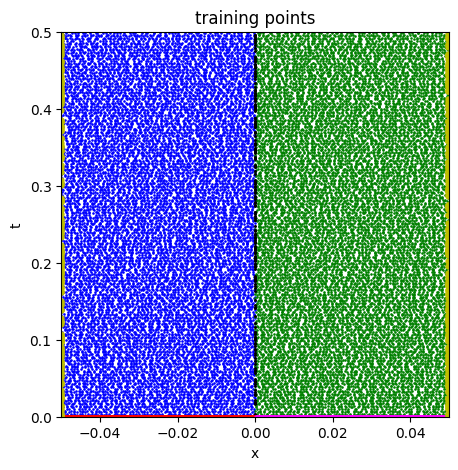

In [23]:
plt.figure(figsize = (5,5))
plt.scatter(X_f1_train[:,0:1], X_f1_train[:,1:2],
            c = "b", s = 3, marker = ".")
plt.scatter(X_f2_train[:,0:1], X_f2_train[:,1:2],
            c = "green", s = 3, marker = ".")
plt.scatter(X_inter[:,0:1], X_inter[:,1:2],
            c = "k", s = 5, marker = ".")
plt.scatter(X_ic1_train[:, 0:1], X_ic1_train[:,1:2],
            c = "r", s = 20, marker = ".")
plt.scatter(X_ic2_train[:, 0:1], X_ic2_train[:,1:2],
            c = "magenta", s = 20, marker = ".")
plt.scatter(X_bcl_train[:, 0:1], X_bcl_train[:,1:2],
            c = "y", s = 50, marker = ".")
plt.scatter(X_bcr_train[:, 0:1], X_bcr_train[:,1:2],
            c = "y", s = 50, marker = ".")

plt.xlabel('x')
plt.ylabel('t')
plt.axis([a_xi, b_xi, a_t, b_t])
plt.title('training points')
plt.savefig(checkpoint_dir + "/training_pts.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
xi_N_ic1_tr = X_ic1_train[:,0:1] # x ic
t_N_ic1_tr = X_ic1_train[:,1:2] # t ic
U_ic1_tr = U_ic1_train #ic
###################################################
xi_N_ic2_tr = X_ic2_train[:,0:1] # x ic
t_N_ic2_tr = X_ic2_train[:,1:2] # t ic
U_ic2_tr = U_ic2_train #ic
###################################################
xi_N_bcl_tr = X_bcl_train[:,0:1] # x ic
t_N_bcl_tr = X_bcl_train[:,1:2] # t ic
U_bcl_tr = U_bcl_train #ic
###################################################
xi_N_bcr_tr = X_bcr_train[:,0:1] # x ic
t_N_bcr_tr = X_bcr_train[:,1:2] # t ic
U_bcr_tr = U_bcr_train #ic
###################################################
xi_f1_tr = X_f1_train[:,0:1]
t_f1_tr = X_f1_train[:,1:2]
###################################################
xi_f2_tr = X_f2_train[:,0:1]
t_f2_tr = X_f2_train[:,1:2]
###################################################
xi_inter_tr = X_inter[:,0:1]
t_inter_tr = X_inter[:,1:2]


In [ ]:
xi_N_ic1_tr = torch.tensor(xi_N_ic1_tr, requires_grad=True).float().to(device)
t_N_ic1_tr = torch.tensor(t_N_ic1_tr, requires_grad=True).float().to(device)
U_ic1_tr = torch.tensor(U_ic1_tr, requires_grad=False).float().to(device)
###############################################################################
xi_N_ic2_tr = torch.tensor(xi_N_ic2_tr, requires_grad=True).float().to(device)
t_N_ic2_tr = torch.tensor(t_N_ic2_tr, requires_grad=True).float().to(device)
U_ic2_tr = torch.tensor(U_ic2_tr, requires_grad=False).float().to(device)
###############################################################################
xi_N_bcl_tr = torch.tensor(xi_N_bcl_tr, requires_grad=True).float().to(device)
t_N_bcl_tr = torch.tensor(t_N_bcl_tr, requires_grad=True).float().to(device)
U_bcl_tr = torch.tensor(U_bcl_tr, requires_grad=False).float().to(device)
###############################################################################
xi_N_bcr_tr = torch.tensor(xi_N_bcr_tr, requires_grad=True).float().to(device)
t_N_bcr_tr = torch.tensor(t_N_bcr_tr, requires_grad=True).float().to(device)
U_bcr_tr = torch.tensor(U_bcr_tr, requires_grad=False).float().to(device)
###############################################################################
xi_f1_tr  = torch.tensor(xi_f1_tr , requires_grad=True).float().to(device)
t_f1_tr = torch.tensor(t_f1_tr, requires_grad=True).float().to(device)
###############################################################################
xi_f2_tr  = torch.tensor(xi_f2_tr , requires_grad=True).float().to(device)
t_f2_tr = torch.tensor(t_f2_tr, requires_grad=True).float().to(device)
###############################################################################
xi_inter_tr  = torch.tensor(xi_inter_tr , requires_grad=True).float().to(device)
t_inter_tr = torch.tensor(t_inter_tr, requires_grad=True).float().to(device)

In [83]:
def net_U(x, t, model):
    U = model(torch.cat([x, t], dim=1))
    return  U

In [ ]:
def net_f(xi_fm, t_fm, xi_fp, t_fp, xi_inter, t_inter, d1 = d1, d2 = d2, k1 = k1, k2 = k2, q1=q1, q2=q2, modelm = ffm, modelp = ffp):

    Um = net_U(xi_fm, t_fm, modelm) 
    Up = net_U(xi_fp, t_fp, modelp) 
    Uinterm = net_U(xi_inter, t_inter, modelm) 
    Uinterp = net_U(xi_inter, t_inter, modelp)

    q1 = q1(xi_fm.cpu().detach().numpy(), t_fm.cpu().detach().numpy())
    q2 = q2(xi_fp.cpu().detach().numpy(), t_fp.cpu().detach().numpy())

    q1_ = torch.tensor(q1, requires_grad=False).float().to(device)
    q2_ = torch.tensor(q2, requires_grad=False).float().to(device)

    ##############################################################################

    dUm_dt = torch.autograd.grad(Um, t_fm, 
                        grad_outputs=torch.ones_like(Um),
                        retain_graph=True,
                        create_graph=True)[0]
    
    dUm_dx = torch.autograd.grad(Um, xi_fm, 
                        grad_outputs=torch.ones_like(Um),
                        retain_graph=True,
                        create_graph=True)[0]
    
    dUm_dxx = torch.autograd.grad(dUm_dx, xi_fm, 
                        grad_outputs=torch.ones_like(dUm_dx),
                        retain_graph=True,
                        create_graph=True)[0]
    
    
    ##############################################################################

    dUp_dt = torch.autograd.grad(Up, t_fp, 
                        grad_outputs=torch.ones_like(Up),
                        retain_graph=True,
                        create_graph=True)[0]
    
    dUp_dx = torch.autograd.grad(Up, xi_fp, 
                        grad_outputs=torch.ones_like(Up),
                        retain_graph=True,
                        create_graph=True)[0]
    
    dUp_dxx = torch.autograd.grad(dUp_dx, xi_fp, 
                        grad_outputs=torch.ones_like(dUp_dx),
                        retain_graph=True,
                        create_graph=True)[0]
    
    
    ##############################################################################

    dUinterm_dx = torch.autograd.grad(Uinterm, xi_inter, 
                        grad_outputs=torch.ones_like(Uinterm),
                        retain_graph=True,
                        create_graph=True)[0]
    
    dUinterp_dx = torch.autograd.grad(Uinterp, xi_inter, 
                        grad_outputs=torch.ones_like(Uinterp),
                        retain_graph=True,
                        create_graph=True)[0]

    ##############################################################################


    fm = dUm_dt - d1*dUm_dxx - q1_*dUm_dx - k1*Um*(1-Um)
    fp = dUp_dt - d2*dUp_dxx - q2_*dUp_dx - k2*Up*(1-Up)


    f_inter = d1*dUinterm_dx - d2*dUinterp_dx
    Uavgi = (Uinterm + Uinterp)/2
    return fm, fp, f_inter, Uavgi, Uinterm, Uinterp

In [ ]:
def loss_function(x_ic1, t_ic1, x_ic2, t_ic2, x_bcl, t_bcl, x_bcr, t_bcr, x_fm, t_fm, x_fp, t_fp, x_inter, t_inter, modelm = ffm, modelp = ffp,\
                   U_ic1_train = U_ic1_tr, U_ic2_train = U_ic2_tr, U_bcl_train = U_bcl_tr, U_bcr_train = U_bcr_tr):
    U_ic1_pred = net_U(x_ic1, t_ic1, modelm) # output of u(x,t)
    U_ic2_pred = net_U(x_ic2, t_ic2, modelp)
    U_bcl_pred = net_U(x_bcl, t_bcl, modelm) 
    U_bcr_pred = net_U(x_bcr, t_bcr, modelp) 
    fm, fp, f_inter, Uavgi, Uinterm, Uinterp = net_f(x_fm, t_fm, x_fp, t_fp, x_inter, t_inter)


    lossm = 20*(torch.mean((U_bcl_train - U_bcl_pred)**2)) \
            + 20*(torch.mean((U_ic1_train - U_ic1_pred)**2)) \
            + torch.mean(fm ** 2) \
            + 40*torch.mean(f_inter ** 2)\
            + 40*torch.mean((Uinterm - Uavgi)**2)
                                 
                    
    lossp = 20*(torch.mean((U_bcr_train - U_bcr_pred)**2)) \
            + 20*(torch.mean((U_ic2_train - U_ic2_pred)**2)) \
            + torch.mean(fp ** 2) \
            + 40*torch.mean(f_inter ** 2)\
            + 40*torch.mean((Uinterp - Uavgi)**2)
    
    return lossm, lossp

In [87]:
loss_function(xi_N_ic1_tr, t_N_ic1_tr, xi_N_ic2_tr, t_N_ic2_tr, xi_N_bcl_tr, t_N_bcl_tr, xi_N_bcr_tr, t_N_bcr_tr, \
              xi_f1_tr, t_f1_tr, xi_f2_tr, t_f2_tr, xi_inter_tr, t_inter_tr)

(tensor(13.8480, device='cuda:1', grad_fn=<AddBackward0>),
 tensor(10.7655, device='cuda:1', grad_fn=<AddBackward0>))

In [88]:
optm = torch.optim.Adam(ffm.parameters())
optp = torch.optim.Adam(ffp.parameters())

schedulerm = torch.optim.lr_scheduler.StepLR(optm, 
                   step_size = 2500, # Period of learning rate decay
                   gamma = 0.95) # Multiplicative factor of learning rate decay

schedulerp = torch.optim.lr_scheduler.StepLR(optp, 
                   step_size = 2500, # Period of learning rate decay
                   gamma = 0.95) # Multiplicative factor of learning rate decay

In [89]:
def train_adam(xi_ic1, t_ic1, xi_ic2, t_ic2, xi_bcl, t_bcl, xi_bcr, t_bcr, xi_fm, t_fm, xi_fp, t_fp, xi_inter, t_inter, \
               opt1 = optm, opt2 = optp, iterations = iter_, sched1 = schedulerm, sched2 = schedulerp):
    lossm_list = []
    lossp_list = []
    loss_ = 1e+50
    
    for epoch in range(iterations):
        epoch = epoch + 1
        optm.zero_grad()
        optp.zero_grad()
        lossm, lossp = loss_function(xi_ic1, t_ic1, xi_ic2, t_ic2, xi_bcl, t_bcl, xi_bcr, t_bcr, \
                                    xi_fm, t_fm, xi_fp, t_fp, xi_inter, t_inter)
        
        lossm_list.append(lossm.item())
        lossp_list.append(lossp.item())
        
        lossm.backward(retain_graph=True)
        lossp.backward(retain_graph=True)

        opt1.step() 
        sched1.step()
        
        opt2.step() 
        sched2.step()
        

        with torch.autograd.no_grad():
            if epoch % 1000 == 0:
                print("epoch: ", epoch)
                print("lossm: ", lossm.item())
                print("lossp: ", lossp.item())
                if lossm.item() + lossp.item() < loss_:
                    loss_ = lossm.item() + lossp.item()
                    epoch_ = epoch
                    torch.save(ffm.state_dict(), checkpoint_path_ffm_best)
                    torch.save(ffp.state_dict(), checkpoint_path_ffp_best)
                    with open (checkpoint_dir + "/info1.txt", 'w') as file:  
                        file.write("best lossm: %s \n best lossp: %s \n at epoch: %s \n" % (str(lossm.item()), str(lossp.item()), str(epoch_)))
                print("best loss at epoch ", epoch_)
                print("-----" * 10)
                torch.save(ffm.state_dict(), checkpoint_path_ffm.format(epoch=epoch))
                torch.save(ffp.state_dict(), checkpoint_path_ffp.format(epoch=epoch))
                dictionary = {'lossm': lossm_list, 'lossp': lossp_list} 
                dataframe = pd.DataFrame(dictionary) 
                dataframe.to_csv(checkpoint_dir + '/loss_adam.csv')

In [ ]:
start_time = time.time()

In [90]:
train_adam(xi_N_ic1_tr, t_N_ic1_tr, xi_N_ic2_tr, t_N_ic2_tr, xi_N_bcl_tr, t_N_bcl_tr, xi_N_bcr_tr, t_N_bcr_tr, \
           xi_f1_tr, t_f1_tr, xi_f2_tr, t_f2_tr, xi_inter_tr, t_inter_tr)

epoch:  1000
lossm:  0.00017909595044329762
lossp:  5.028068699175492e-05
best loss at epoch  1000
--------------------------------------------------


In [ ]:
end_time = time.time()
elapsed_time = end_time - start_time
print(elapsed_time)

In [ ]:
with open(checkpoint_dir + "/time_train_cpinn.txt", 'w') as file:
    file.write(f"Time: {str(elapsed_time)}") 